# Evaluate ElevenLabs Scribe on the Bisaya Corpus

Runs ElevenLabs Scribe (a commercial ASR API) over the full Bisaya corpus
and computes raw (non-normalized) WER/CER against the reference
transcripts. Normalization and cross-system comparison against Kaldi live
in `compare.ipynb`, not here.

**Environment:** plain Python (no WSL/Kaldi dependency). Needs `pandas`,
`pyarrow`, `python-dotenv`, `elevenlabs`, `jiwer`, `matplotlib`, and a
`.env` file (git-ignored) providing `ELEVENLABS_API_KEY`.


## 1. Load Libraries

In [1]:
import os
from io import BytesIO
from pathlib import Path

import pandas as pd

# Shared with evaluate_kaldi.ipynb/compare.ipynb -- results land in
# output/elevenlabs/, alongside output/kaldi/ and output/tri3/.
RESULTS_DIR = Path(os.environ.get("BISAYA_RESULTS_DIR", "../output")).resolve()
(RESULTS_DIR / "elevenlabs").mkdir(parents=True, exist_ok=True)


## 2. API Key

Kept in its own cell so the key can be reloaded (e.g. after swapping to a
fresh one in `.env`) without re-running the cells above it.

In [2]:
from dotenv import load_dotenv
from elevenlabs.client import ElevenLabs

load_dotenv(override=True)
model = ElevenLabs(api_key=os.getenv("ELEVENLABS_API_KEY"))


## 3. Load Corpus

In [3]:
CORPUS_DIR = Path(os.environ.get("BISAYA_CORPUS_DIR", "../data/bisaya_audio")).resolve()
parquet_files = sorted(CORPUS_DIR.glob("*.parquet"))

for file in parquet_files:
    df_temp = pd.read_parquet(file)
    print(f"{file.name}: {len(df_temp):,} rows")


test-00000-of-00011.parquet: 7 rows


test-00001-of-00011.parquet: 11 rows


test-00002-of-00011.parquet: 9 rows


test-00003-of-00011.parquet: 4 rows


test-00004-of-00011.parquet: 6 rows


test-00005-of-00011.parquet: 5 rows


test-00006-of-00011.parquet: 7 rows


test-00007-of-00011.parquet: 14 rows


test-00008-of-00011.parquet: 18 rows


test-00009-of-00011.parquet: 5 rows
test-00010-of-00011.parquet: 4 rows


In [4]:
dfs = []

for file in parquet_files:
    temp = pd.read_parquet(file)
    parquet_num = int(file.stem.split("-")[1])
    temp["row"] = range(1, len(temp) + 1)
    temp["id"] = temp["row"].apply(lambda x: f"{parquet_num:03d}_{x:03d}")
    temp["parquet_file"] = file.name
    dfs.append(temp)

data_df = pd.concat(dfs, ignore_index=True)

# Row position in this concatenation -- the join key compare.ipynb uses to
# line results up with evaluate_kaldi.ipynb's own corpus loading (same
# sorted-glob + ignore_index=True order).
data_df["corpus_index"] = data_df.index


### Corpus metadata distribution

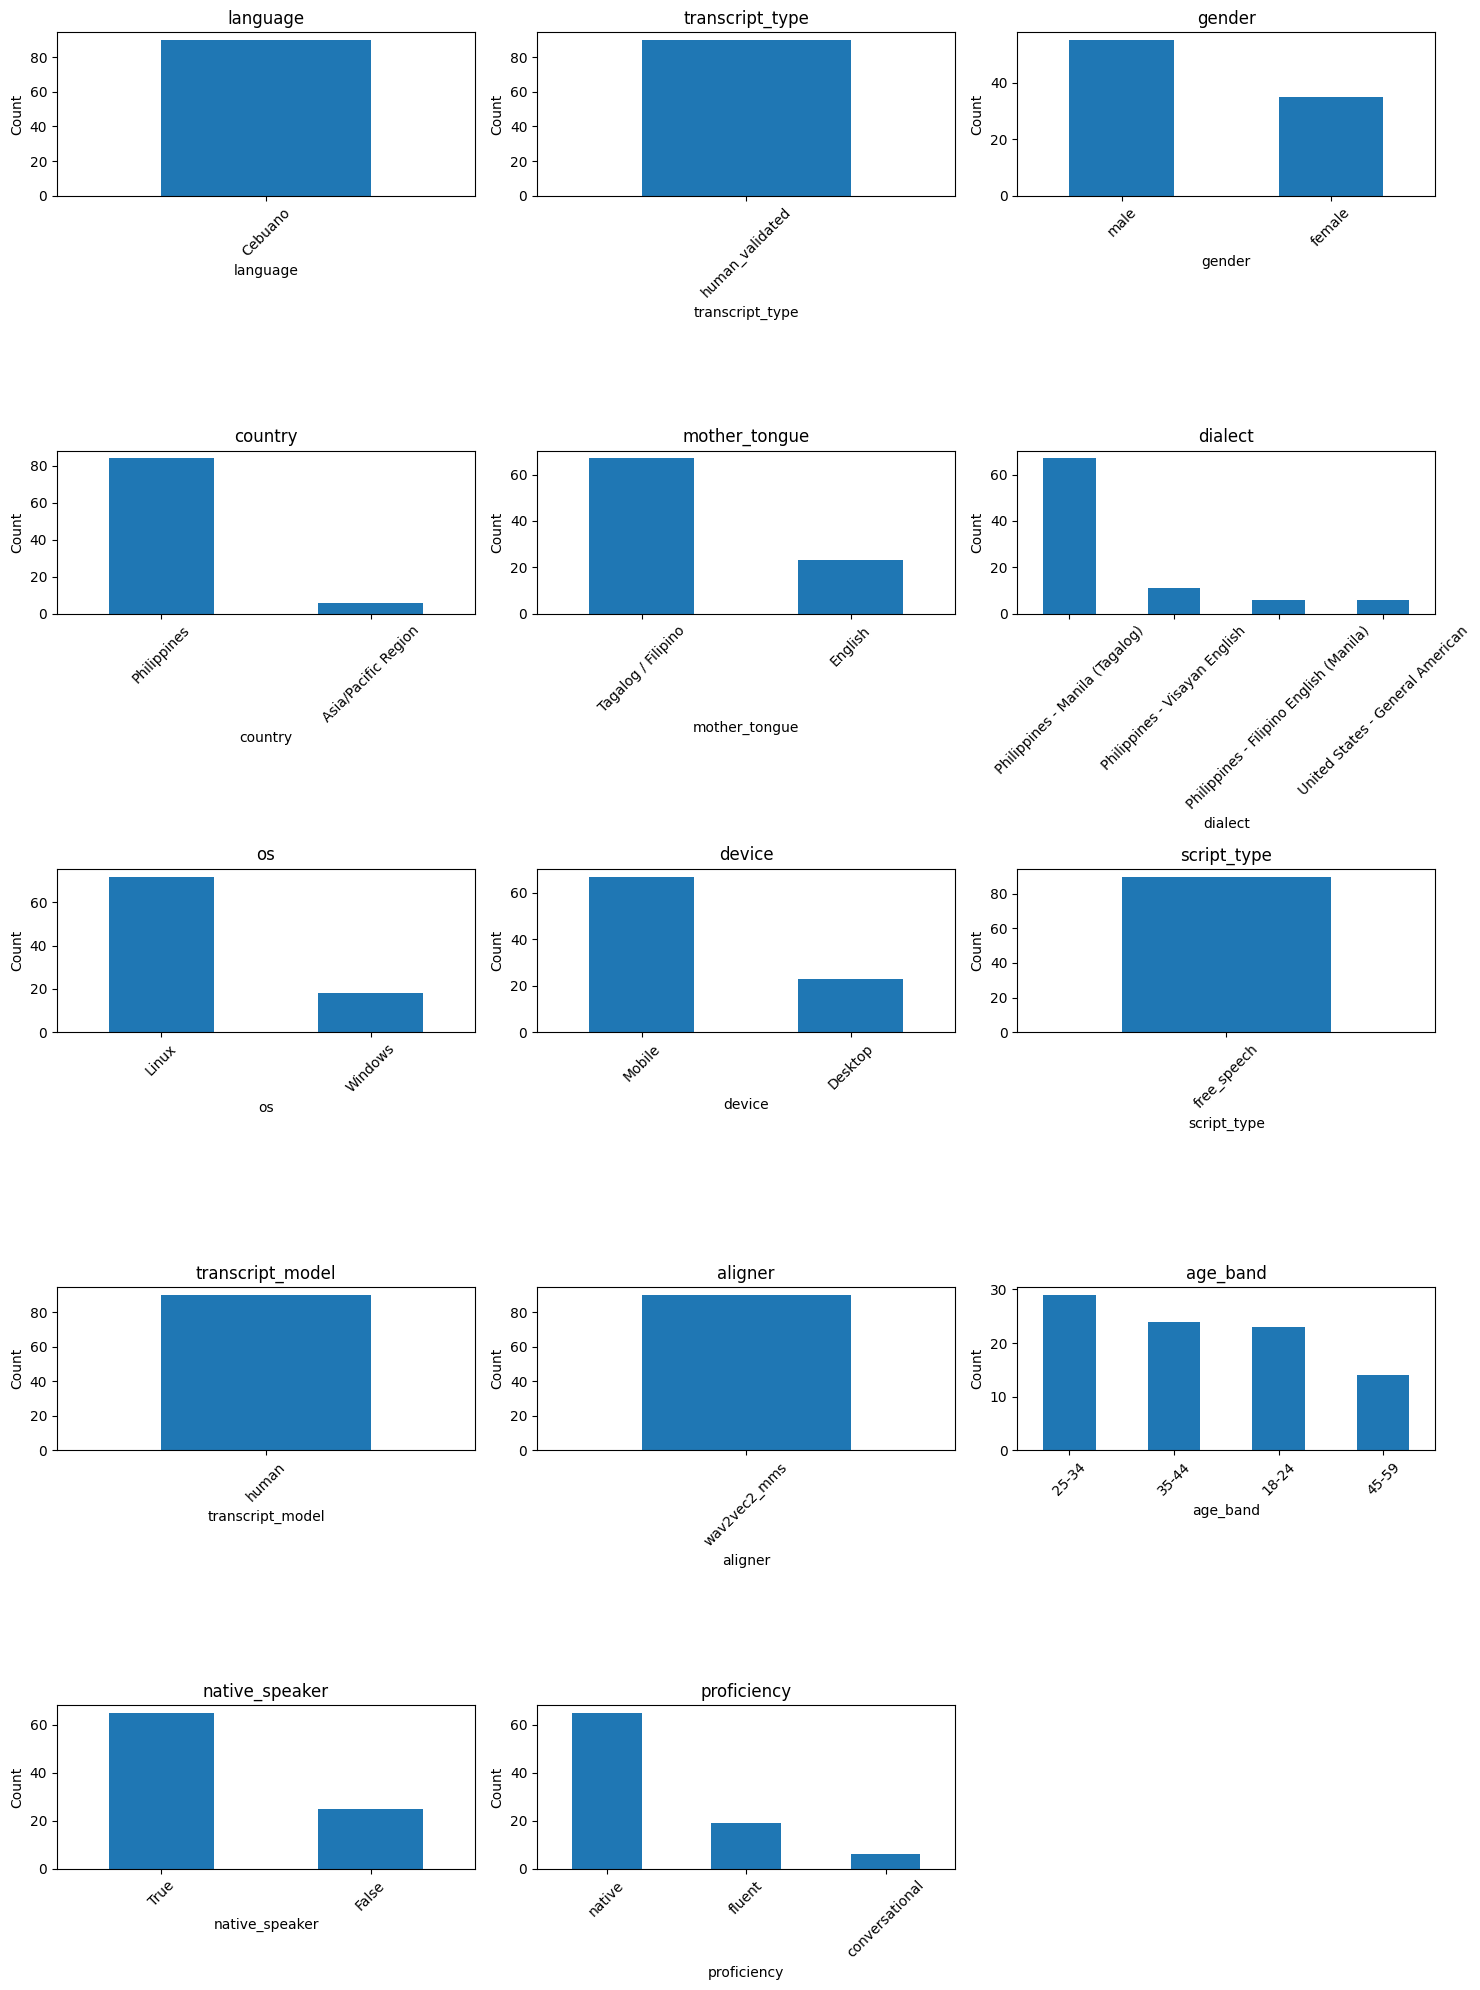

In [5]:
import matplotlib.pyplot as plt

exclude = ["audio", "speaker_id", "transcript", "duration", "words", "n_words", "row", "id", "parquet_file", "corpus_index"]
cols = [col for col in data_df.columns if col not in exclude]

fig, axes = plt.subplots(nrows=(len(cols) + 2) // 3, ncols=3, figsize=(15, 4 * ((len(cols) + 2) // 3)))
axes = axes.flatten()

for ax, col in zip(axes, cols):
    data_df[col].value_counts(dropna=False).plot(kind="bar", ax=ax)
    ax.set_title(col)
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=45)

for ax in axes[len(cols):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


## 4. Transcribe via ElevenLabs

Resumable: any `id` already present in the checkpoint file is skipped, so
this can be safely re-run after an interruption (e.g. running out of API
credits -- swap the key in `.env` and re-run Section 2, then this cell).

In [6]:
CHECKPOINT_PATH = str(RESULTS_DIR / "elevenlabs" / "scribe_raw_results.parquet")

if Path(CHECKPOINT_PATH).exists():
    checkpoint_df = pd.read_parquet(CHECKPOINT_PATH)
else:
    checkpoint_df = pd.DataFrame(
        columns=["id", "corpus_index", "parquet_file", "row", "speaker_id", "reference", "prediction"]
    )

completed_ids = set(checkpoint_df["id"])
checkpoint_records = checkpoint_df.to_dict("records")

def save_checkpoint(records):
    tmp_path = CHECKPOINT_PATH + ".tmp"
    pd.DataFrame(records).to_parquet(tmp_path, index=False)
    os.replace(tmp_path, CHECKPOINT_PATH)

print(f"Checkpoint loaded: {len(completed_ids)} samples already transcribed.")
print(f"Remaining to process: {len(data_df) - len(completed_ids)} / {len(data_df)}")


Checkpoint loaded: 90 samples already transcribed.
Remaining to process: 0 / 90


In [7]:
for _, row in data_df.iterrows():

    sample_id = row["id"]
    if sample_id in completed_ids:
        continue

    print(f"{row['parquet_file']} — id {sample_id}")

    audio_file = BytesIO(row["audio"]["bytes"])

    try:
        result = model.speech_to_text.convert(
            file=audio_file,
            model_id="scribe_v2",
            language_code="ceb"
        )
    except Exception as e:
        print(f"  FAILED on {sample_id}: {e}")
        print("  Stopping (further calls will likely fail the same way). "
              "Fix the issue and rerun this cell -- it resumes automatically.")
        break

    checkpoint_records.append({
        "id": sample_id,
        "corpus_index": row["corpus_index"],
        "parquet_file": row["parquet_file"],
        "row": row["row"],
        "speaker_id": row["speaker_id"],
        "reference": row["transcript"],
        "prediction": result.text
    })
    completed_ids.add(sample_id)
    save_checkpoint(checkpoint_records)

print(f"\nDone this run. Total transcribed so far: {len(checkpoint_records)} / {len(data_df)}")



Done this run. Total transcribed so far: 90 / 90


## 5. Raw WER/CER

Word Error Rate and Character Error Rate on the **raw** (non-normalized)
text pair, from substitutions (S), deletions (D), insertions (I), and
hits (H):

$$
\mathrm{WER} = \frac{S + D + I}{H + S + D}
\qquad
\mathrm{CER} = \frac{S + D + I}{H + S + D}
$$

(word-level for WER, character-level for CER). Normalized metrics are
computed later in `compare.ipynb`, from this notebook's saved
reference/prediction text -- not here.

In [8]:
# Run this cell (after Section 1's imports) to skip straight to metrics
# without re-running Section 2 (API key) or Section 4 (transcription,
# which costs API credits) -- reloads already-saved transcriptions.
CHECKPOINT_PATH = str(RESULTS_DIR / "elevenlabs" / "scribe_raw_results.parquet")
results_df = pd.read_parquet(CHECKPOINT_PATH)
print(results_df.count())


parquet_file    90
row             90
speaker_id      90
reference       90
prediction      90
id              90
dtype: int64


In [9]:
from jiwer import process_words, process_characters

results = []
for _, row in results_df.iterrows():
    reference, prediction = row["reference"], row["prediction"]
    word_result = process_words(reference, prediction)
    char_result = process_characters(reference, prediction)

    results.append({
        "id": row["id"],
        "WER": word_result.wer,
        "WER_sub": word_result.substitutions,
        "WER_del": word_result.deletions,
        "WER_ins": word_result.insertions,
        "WER_hits": word_result.hits,
        "CER": char_result.cer,
        "CER_sub": char_result.substitutions,
        "CER_del": char_result.deletions,
        "CER_ins": char_result.insertions,
        "CER_hits": char_result.hits,
    })

metrics_df = pd.DataFrame(results)
metrics_df.head()


,id,WER,WER_sub,WER_del,WER_ins,WER_hits,CER,CER_sub,CER_del,CER_ins,CER_hits
0,007_001,0.078947,12,2,1,176,0.028829,13,9,10,1088
1,007_002,0.068441,12,3,3,248,0.025917,4,23,14,1555
2,007_003,0.031963,7,0,0,212,0.008842,6,2,3,1236
3,007_004,0.107011,22,4,3,245,0.043643,24,22,23,1535
4,007_005,0.040230,6,1,0,167,0.009018,3,6,0,989


## 6. Assemble Results for Export

In [10]:
META_COLS = [
    "speaker_id", "language", "gender", "country", "mother_tongue", "dialect",
    "os", "device", "n_words", "age_band", "native_speaker", "proficiency",
]

analysis_df = data_df[META_COLS + ["id", "corpus_index"]].merge(
    results_df[["id", "reference", "prediction"]], on="id", how="left",
).merge(
    metrics_df[["id", "WER", "WER_sub", "WER_del", "WER_ins", "WER_hits",
                 "CER", "CER_sub", "CER_del", "CER_ins", "CER_hits"]],
    on="id", how="left",
)
analysis_df.head()


,speaker_id,language,gender,country,mother_tongue,dialect,os,device,n_words,age_band,...,WER,WER_sub,WER_del,WER_ins,WER_hits,CER,CER_sub,CER_del,CER_ins,CER_hits
0,CEB_008,Cebuano,male,Philippines,Tagalog / Filipino,Philippines - Manila (Tagalog),Linux,Mobile,219,45-59,...,0.041096,8,1,0,210,0.009569,5,3,4,1246
1,CEB_008,Cebuano,male,Philippines,Tagalog / Filipino,Philippines - Manila (Tagalog),Linux,Mobile,138,45-59,...,0.057971,6,2,0,130,0.012486,4,6,1,871
2,CEB_008,Cebuano,male,Philippines,Tagalog / Filipino,Philippines - Manila (Tagalog),Linux,Mobile,260,45-59,...,0.038462,7,1,2,252,0.009276,2,3,10,1612
3,CEB_008,Cebuano,male,Philippines,Tagalog / Filipino,Philippines - Manila (Tagalog),Linux,Mobile,475,45-59,...,0.073684,34,0,1,441,0.011925,25,10,0,2900
4,CEB_008,Cebuano,male,Philippines,Tagalog / Filipino,Philippines - Manila (Tagalog),Linux,Mobile,216,45-59,...,0.041667,7,2,0,207,0.007294,3,2,5,1366


## 7. Single-System Analysis (Raw Metrics Only)

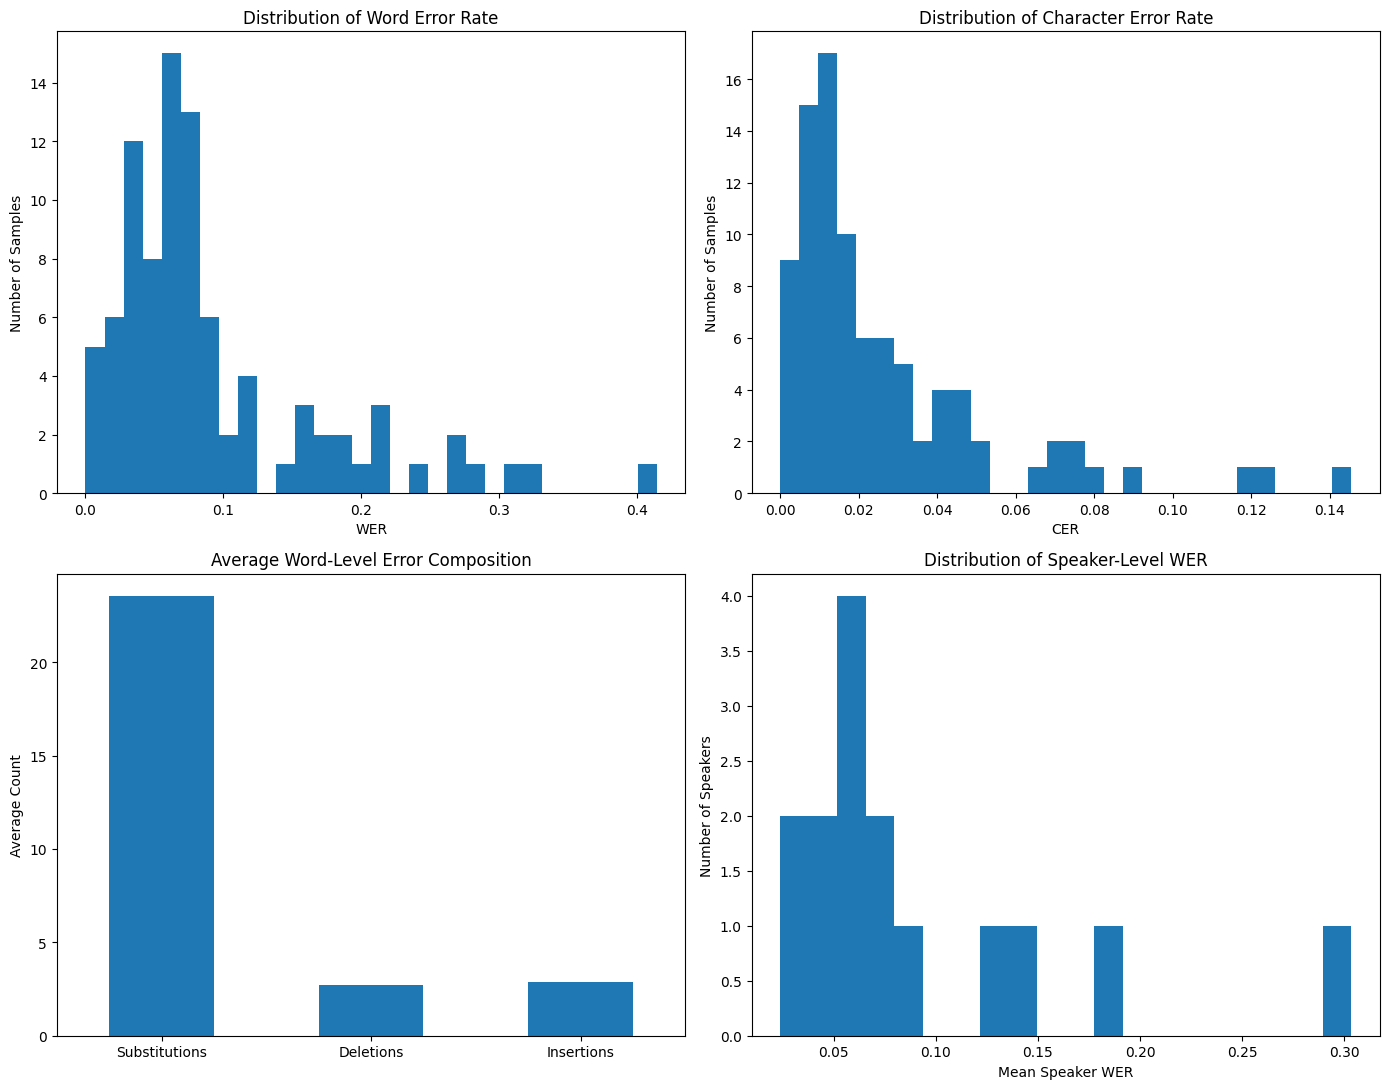

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

axes[0, 0].hist(analysis_df["WER"], bins=30)
axes[0, 0].set_xlabel("WER")
axes[0, 0].set_ylabel("Number of Samples")
axes[0, 0].set_title("Distribution of Word Error Rate")

axes[0, 1].hist(analysis_df["CER"], bins=30)
axes[0, 1].set_xlabel("CER")
axes[0, 1].set_ylabel("Number of Samples")
axes[0, 1].set_title("Distribution of Character Error Rate")

error_means = analysis_df[["WER_sub", "WER_del", "WER_ins"]].mean()
error_means.index = ["Substitutions", "Deletions", "Insertions"]
error_means.plot(kind="bar", ax=axes[1, 0])
axes[1, 0].set_ylabel("Average Count")
axes[1, 0].set_title("Average Word-Level Error Composition")
axes[1, 0].tick_params(axis="x", rotation=0)

speaker_wer = analysis_df.groupby("speaker_id")["WER"].mean()
axes[1, 1].hist(speaker_wer, bins=20)
axes[1, 1].set_xlabel("Mean Speaker WER")
axes[1, 1].set_ylabel("Number of Speakers")
axes[1, 1].set_title("Distribution of Speaker-Level WER")

plt.tight_layout()
plt.show()


## 8. Export for Comparison

Writes per-utterance reference/prediction, demographics, and raw WER/CER
to `output/elevenlabs/results.csv` -- `compare.ipynb` reads this alongside
`output/kaldi/results.csv`, applies normalization, and does the
cross-system comparison.

In [12]:
EXPORT_PATH = RESULTS_DIR / "elevenlabs" / "results.csv"
analysis_df.to_csv(EXPORT_PATH, index=False)
print(f"Wrote {len(analysis_df)} rows to {EXPORT_PATH}")


Wrote 90 rows to C:\Users\windows 10\Documents\Sugbodoc\speech model\output\elevenlabs\results.csv
